# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from svm_lib import SVM

# Seed fixe pour la reproductibilite des experiences (donnees generees
# aleatoirement identiques a chaque execution du notebook).
np.random.seed(42)


# Cas de tests, rendu 2

## Classification

### Linear Simple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [2]:
X = np.array([
      [1, 1],
      [2, 3],
      [3, 3]
])
Y = np.array([
      1,
      -1,
      -1
])

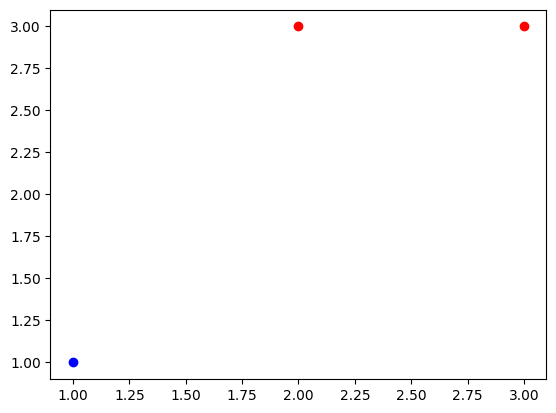

<Figure size 640x480 with 0 Axes>

In [3]:
plt.scatter(X[0, 0], X[0, 1], color='blue')
plt.scatter(X[1:3,0], X[1:3,1], color='red')
plt.show()
plt.clf()

SVM Linear Simple — Accuracy: 100.0%, Vecteurs supports: 2/3, Iterations: 182


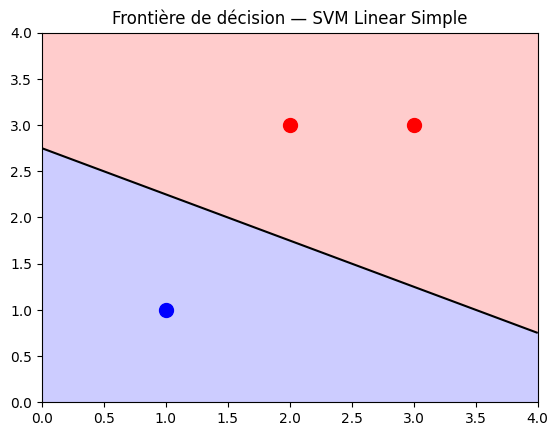

In [4]:
# Test SVM Linear Simple
model = SVM(kernel='linear', max_iter=200000)
model.fit(X, Y)
print(f"SVM Linear Simple — Accuracy: {model.accuracy(X, Y)*100:.1f}%, "
      f"Vecteurs supports: {model.n_support_vectors()}/{len(Y)}, "
      f"Iterations: {model.n_iterations_used()}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(0, 4, 300), np.linspace(0, 4, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = model.decision_function(grid).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0, 0], X[0, 1], color='blue', s=100, zorder=5)
plt.scatter(X[1:3, 0], X[1:3, 1], color='red', s=100, zorder=5)
plt.title("Frontière de décision — SVM Linear Simple")
plt.show()


### Linear Multiple :
        Linear Model : OK
        MLP (2, 1)   : OK

In [5]:
X = np.concatenate([np.random.random((50,2)) * 0.9 + np.array([1, 1]), np.random.random((50,2)) * 0.9 + np.array([2, 2])])
Y = np.concatenate([np.ones((50, 1)), np.ones((50, 1)) * -1.0])

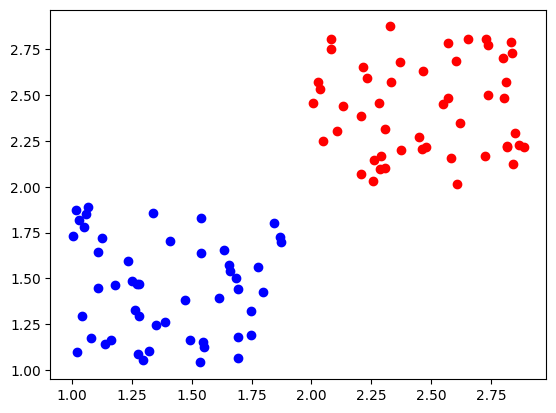

<Figure size 640x480 with 0 Axes>

In [6]:
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue')
plt.scatter(X[50:100,0], X[50:100,1], color='red')
plt.show()
plt.clf()

SVM Linear Multiple — Accuracy: 100.0%, Vecteurs supports: 4/100, Iterations: 200000


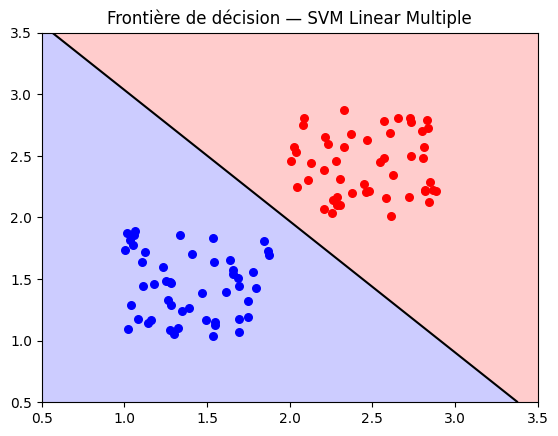

In [7]:
# Test SVM Linear Multiple
Y_flat = Y.flatten().astype(int)
model = SVM(kernel='linear', max_iter=200000)
model.fit(X, Y_flat)
print(f"SVM Linear Multiple — Accuracy: {model.accuracy(X, Y_flat)*100:.1f}%, "
      f"Vecteurs supports: {model.n_support_vectors()}/{len(Y_flat)}, "
      f"Iterations: {model.n_iterations_used()}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(0.5, 3.5, 300), np.linspace(0.5, 3.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = model.decision_function(grid).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:50, 0], X[0:50, 1], color='blue', s=30, zorder=5)
plt.scatter(X[50:100, 0], X[50:100, 1], color='red', s=30, zorder=5)
plt.title("Frontière de décision — SVM Linear Multiple")
plt.show()


### XOR :
        Linear Model    : KO
        MLP (2, 2, 1)   : OK

In [8]:
X = np.array([[1, 0], [0, 1], [0, 0], [1, 1]])
Y = np.array([1, 1, -1, -1])

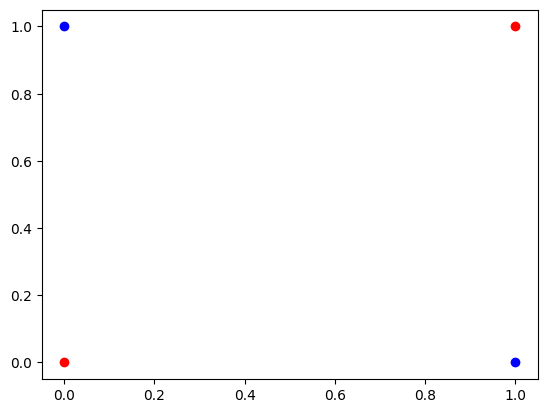

<Figure size 640x480 with 0 Axes>

In [9]:
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue')
plt.scatter(X[2:4,0], X[2:4,1], color='red')
plt.show()
plt.clf()

SVM XOR (RBF) — Accuracy: 100.0%, Vecteurs supports: 4/4, Iterations: 54


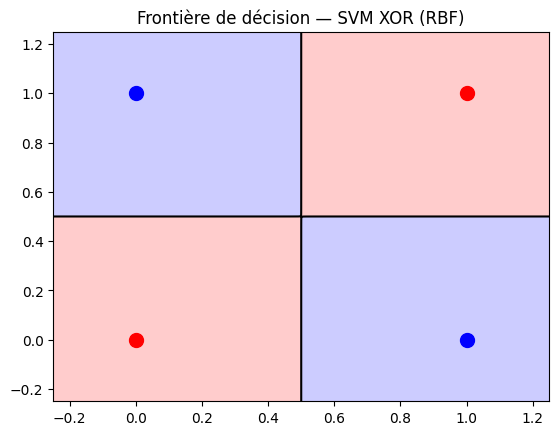

In [10]:
# Test SVM XOR (noyau RBF car non linéairement séparable)
model = SVM(kernel='rbf', gamma=2.0, max_iter=200000)
model.fit(X, Y)
print(f"SVM XOR (RBF) — Accuracy: {model.accuracy(X, Y)*100:.1f}%, "
      f"Vecteurs supports: {model.n_support_vectors()}/{len(Y)}, "
      f"Iterations: {model.n_iterations_used()}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300), np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = model.decision_function(grid).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[0:2, 0], X[0:2, 1], color='blue', s=100, zorder=5)
plt.scatter(X[2:4, 0], X[2:4, 1], color='red', s=100, zorder=5)
plt.title("Frontière de décision — SVM XOR (RBF)")
plt.show()


























































































### Cross :
        Linear Model    : KO
        MLP (2, 4, 1)   : OK

In [11]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([1 if abs(p[0]) <= 0.3 or abs(p[1]) <= 0.3 else -1 for p in X])

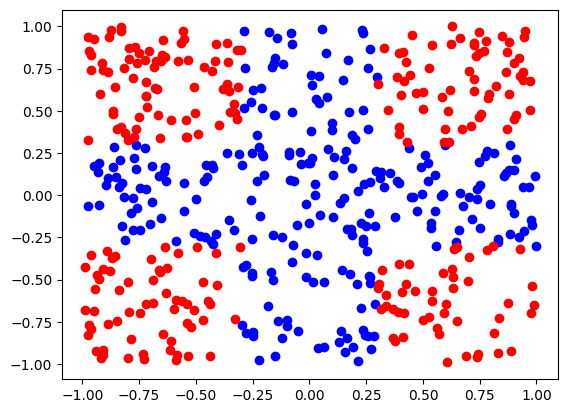

<Figure size 640x480 with 0 Axes>

In [12]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]] == -1, enumerate(X)))))[:,1], color='red')
plt.show()
plt.clf()

SVM Cross (RBF) — Accuracy: 100.0%, Vecteurs supports: 75/500, Iterations: 200000


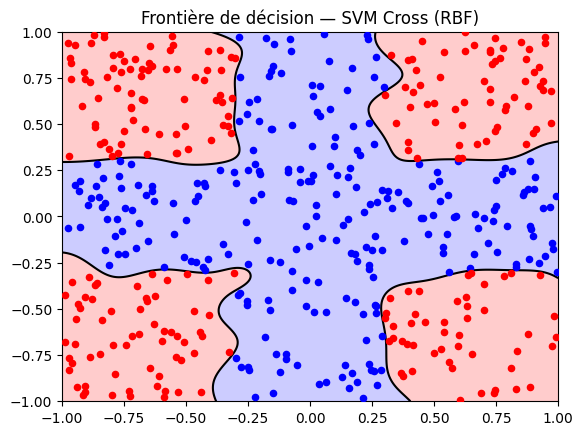

In [13]:
# Test SVM Cross (noyau RBF car non linéairement séparable)
model = SVM(kernel='rbf', gamma=25.0, max_iter=200000)
model.fit(X, Y)
print(f"SVM Cross (RBF) — Accuracy: {model.accuracy(X, Y)*100:.1f}%, "
      f"Vecteurs supports: {model.n_support_vectors()}/{len(Y)}, "
      f"Iterations: {model.n_iterations_used()}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores = model.decision_function(grid).reshape(xx.shape)

plt.contourf(xx, yy, scores, levels=[-np.inf, 0, np.inf], colors=['#ffaaaa', '#aaaaff'], alpha=0.6)
plt.contour(xx, yy, scores, levels=[0], colors='black', linewidths=1.5)
plt.scatter(X[Y == 1, 0], X[Y == 1, 1], color='blue', s=20, zorder=5)
plt.scatter(X[Y == -1, 0], X[Y == -1, 1], color='red', s=20, zorder=5)
plt.title("Frontière de décision — SVM Cross (RBF)")
plt.show()


### Multi Linear 3 classes :
        Linear Model x3 : OK
        MLP (2, 3)      : OK

In [14]:
X = np.random.random((500, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if -p[0] - p[1] - 0.5 > 0 and p[1] < 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, 1, -1] if -p[0] - p[1] - 0.5 < 0 and p[1] > 0 and p[0] - p[1] - 0.5 < 0 else
              [-1, -1, 1] if -p[0] - p[1] - 0.5 < 0 and p[1] < 0 and p[0] - p[1] - 0.5 > 0 else
              [-1, -1, -1]for p in X])

X = X[[not np.all(arr == [-1, -1, -1]) for arr in Y]]
Y = Y[[not np.all(arr == [-1, -1, -1]) for arr in Y]]

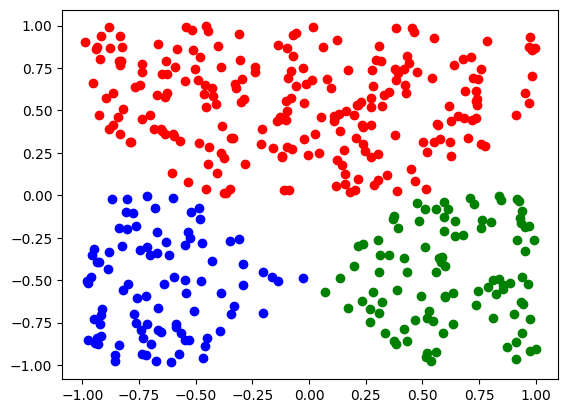

<Figure size 640x480 with 0 Axes>

In [15]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

SVM Multi Linear 3 classes (One-vs-All) — Accuracy: 99.8%, Iterations par classifieur: [200000, 200000, 200000]


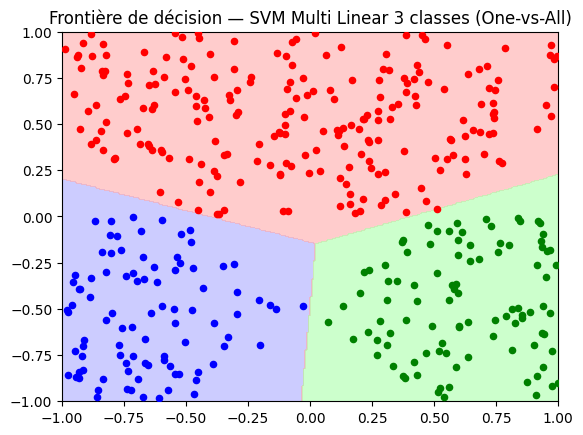

In [16]:
# Test SVM Multi Linear 3 classes (One-vs-All : 3 SVMs)
models = []
for i in range(3):
    Y_bin = np.array([1 if y[i] == 1 else -1 for y in Y])
    model = SVM(kernel='linear', max_iter=200000)
    model.fit(X, Y_bin)
    models.append(model)

# Prédiction : classe avec le score le plus élevé
scores = np.array([m.decision_function(X) for m in models]).T
preds = np.argmax(scores, axis=1)
Y_true = np.argmax(Y, axis=1)
acc = np.mean(preds == Y_true)
iters = [m.n_iterations_used() for m in models]
print(f"SVM Multi Linear 3 classes (One-vs-All) — Accuracy: {acc*100:.1f}%, Iterations par classifieur: {iters}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores_grid = np.array([m.decision_function(grid) for m in models]).T
classes = np.argmax(scores_grid, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue', s=20, zorder=5)
plt.scatter(red[:,0], red[:,1], color='red', s=20, zorder=5)
plt.scatter(green[:,0], green[:,1], color='green', s=20, zorder=5)
plt.title("Frontière de décision — SVM Multi Linear 3 classes (One-vs-All)")
plt.show()


### Multi Cross :
        Linear Model x3 : KO
        MLP (2, ?, ?, 3): OK

In [17]:
# NOTE : le solveur QP (gradient projete) est en O(n^2) par iteration.
# Avec n=1000 et 3 classifieurs one-vs-rest, l'entrainement devient tres
# long (dizaines de minutes) dans cet environnement. On reduit a 300
# points pour rester praticable (meme choix que dans main.c) ; a
# remonter si tu disposes de plus de temps de calcul.
X = np.random.random((300, 2)) * 2.0 - 1.0
Y = np.array([[1, -1, -1] if abs(p[0] % 0.5) <= 0.25 and abs(p[1] % 0.5) > 0.25 else [-1, 1, -1] if abs(p[0] % 0.5) > 0.25 and abs(p[1] % 0.5) <= 0.25 else [-1, -1, 1] for p in X])


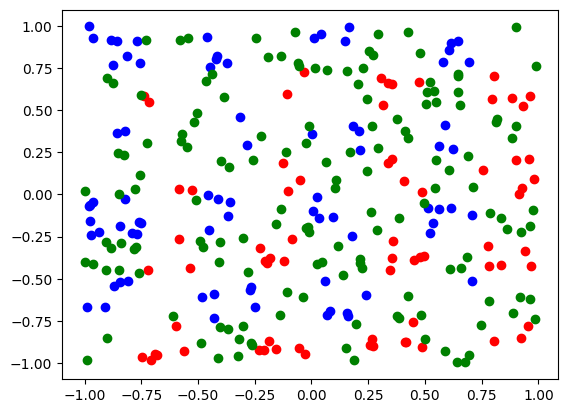

<Figure size 640x480 with 0 Axes>

In [18]:
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][0] == 1, enumerate(X)))))[:,1], color='blue')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][1] == 1, enumerate(X)))))[:,1], color='red')
plt.scatter(np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,0], np.array(list(map(lambda elt : elt[1], filter(lambda c: Y[c[0]][2] == 1, enumerate(X)))))[:,1], color='green')
plt.show()
plt.clf()

SVM Multi Cross (One-vs-All, RBF) — Accuracy: 98.7%, Iterations par classifieur: [200000, 200000, 200000]


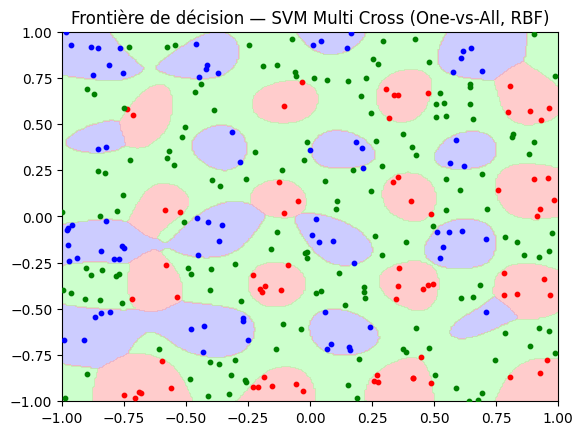

In [19]:
# Test SVM Multi Cross (One-vs-All : 3 SVMs avec noyau RBF)
models = []
for i in range(3):
    Y_bin = np.array([1 if y[i] == 1 else -1 for y in Y])
    model = SVM(kernel='rbf', gamma=10.0, max_iter=200000)
    model.fit(X, Y_bin)
    models.append(model)

# Prédiction : classe avec le score le plus élevé
scores = np.array([m.decision_function(X) for m in models]).T
preds = np.argmax(scores, axis=1)
Y_true = np.argmax(Y, axis=1)
acc = np.mean(preds == Y_true)
iters = [m.n_iterations_used() for m in models]
print(f"SVM Multi Cross (One-vs-All, RBF) — Accuracy: {acc*100:.1f}%, Iterations par classifieur: {iters}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-1, 1, 300), np.linspace(-1, 1, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
scores_grid = np.array([m.decision_function(grid) for m in models]).T
classes = np.argmax(scores_grid, axis=1).reshape(xx.shape)

plt.contourf(xx, yy, classes, levels=[-0.5, 0.5, 1.5, 2.5], colors=['#aaaaff', '#ffaaaa', '#aaffaa'], alpha=0.6)

blue = X[Y[:, 0] == 1]
red = X[Y[:, 1] == 1]
green = X[Y[:, 2] == 1]

plt.scatter(blue[:,0], blue[:,1], color='blue', s=10, zorder=5)
plt.scatter(red[:,0], red[:,1], color='red', s=10, zorder=5)
plt.scatter(green[:,0], green[:,1], color='green', s=10, zorder=5)
plt.title("Frontière de décision — SVM Multi Cross (One-vs-All, RBF)")
plt.show()
